# Homework09

Exercises to practice dimensionality reduction with PCA

## Goals

- Add unsupervised pre-processing to our ML flow: encode -> normalize -> pre-process -> train -> evaluate
- Build an intuition for PCA and when/how to use it
- Understand the benefits of dimensionality reduction

### Setup

Run the following 2 cells to import all necessary libraries and helpers for this homework.

In [1]:
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/data_utils.py
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/image_utils.py
!wget -q https://github.com/PSAM-5020-2026S-A/Homework07/raw/main/Homework07_utils.pyc

!wget -qO- https://github.com/PSAM-5020-2026S-A/5020-utils/releases/latest/download/0801-500.tar.gz | tar xz

In [2]:
from os import listdir, path
from PIL import Image as PImage

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

from image_utils import get_pixels, make_image

from Homework07_utils import CamUtils

## PCA and Classification

Let's practice doing some more image classification with `PCA` and analyzing the results.

The dataset is the same one we used in `Homework07`. It has images from $25$ different security cameras, and our task is to separate them by camera. Some of the cameras move, some of them don't, and there are more than $1000$ images, so there's no way we want to do this by hand.

Let's start by loading the training images into a list of pixels, like we did with the `faces` dataset in class.

### Loading Data

If we look at the images in `./data/image/0801-500/train/`, we'll notice that they are named and organized in a slightly different way. They're all in the same directory and the first part of their filename specifies which camera they came from. Even though those `ids` are numbers, they're not sequential, so we'll use some helper functions to extract a unique `label` from their filenames.

This is exactly what the `OrdinalEncoder` class does, but since we only have to encode this one column, we'll do it by hand while we read the files in.

In [3]:
# this creates a list of all the files in a given directory, that end in .jpg
train_files = [f for f in listdir("./data/image/0801-500/train") if f.endswith(".jpg")]

In [4]:
# TODO: check and see what is inside the list here
train_files[:5]

['03-05.jpg', '28-69.jpg', '26-50.jpg', '07-75.jpg', '23-60.jpg']

Now we'll read the image pixels and extract their labels. `CamUtils.get_label()` is the helper function we'll use to "encode" and return a label id based on the filename.

In [5]:
pixel_data = []
label_data = []

for fname in train_files:
  label = CamUtils.get_label(fname)
  img = PImage.open(path.join("./data/image/0801-500/train", fname))
  pixel_data.append(get_pixels(img))
  label_data.append(label)

In [12]:
# TODO: check if labels got extracted correctly by looking at 
#       the first few items of the label list and the filename list
label_data[:5]
print(len(label_data))

250


Like in `Homework07`, the labels and the filenames won't match exactly since labels start at $0$ and the filenames start at $01$ and skip some numbers.

We can open some images from pixels, just to make sure we loaded them correctly:

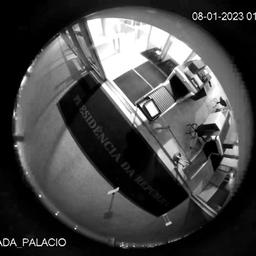

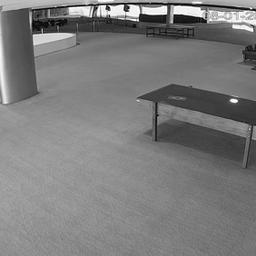

In [13]:
display(make_image(pixel_data[0]))
display(make_image(pixel_data[10]))

### PCA

Create a `DataFrame` called `cam_pca_df` by running `PCA` on the list of pixel data, just like we did in class, and then append a `label` column to it, just like we did in Homework07 with: `train_df["label"] = label_data`.

You can change how many components to extract from the images later, but for this first run just use $10$ components so we can compare classification with $10$ `PCA` components to the classification with $10$ random features from `Homework07`.  Make sure to confirm how much of the `variance` is preserved by this transformation.

In [16]:
# TODO: run PCA, get DataFrame
pca = PCA(n_components=10).set_output(transform="pandas")
cam_pca_df = pca.fit_transform(pixel_data)
# TODO: add "label" column
cam_pca_df["label"] = label_data
# TODO: print variance
print(sum(pca.explained_variance_ratio_))
# TODO: take a look at the first 5 rows
cam_pca_df.head()

0.7852542516955628


,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,label
0,-15175.500144,-218.500037,2079.647832,-8805.120490,10356.778081,2842.013074,-898.322289,1276.409939,-2261.945487,-685.957280,2
1,9125.143626,-2757.956261,1513.736748,-1653.929944,-3465.050612,1121.506628,-1399.534681,740.603198,844.260034,-534.628657,23
2,1607.567810,-374.751928,3798.243027,3831.104363,-1028.044047,590.142063,-2516.341335,-4317.105068,465.761217,-141.888857,21
3,8649.197440,-6626.161473,3316.282913,-3755.654516,-2167.127795,426.670911,-3197.219498,5857.837470,1383.462281,-3279.921238,5
4,1504.558974,-6677.503456,-3184.917455,8828.289354,1700.775307,6255.206039,3707.693549,-1655.668857,-1586.196663,-2858.679443,18


### Interpretation

<span style="color:hotpink">
How many components did you keep ?<br>
Did you try different numbers ?<br>
What percent of variance is kept by this transformation?
</span>

So I try with 10 principle components, and the variance kept about 79 percent of the original dataset.

### Reconstruct

Before we go run our classification, let's take a look at some reconstructed images, just to make sure they make sense.

Take a look at reconstructed versions of images $0$, $10$, and whichever other images you might have opened above.

We did this in class. It involves a `inverse_transform()` function.

65536


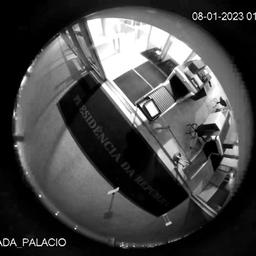

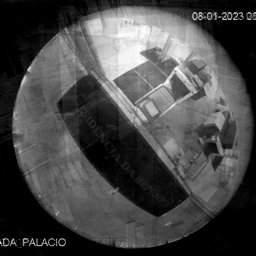

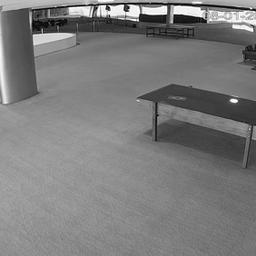

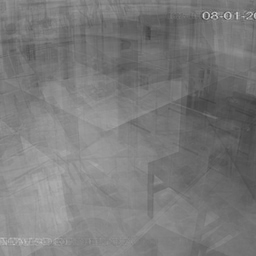

In [49]:
# TODO: reconstruct image at index 0
mimg = PImage.open(path.join("./data/image/0801-500/train", train_files[10]))
iw, ih = mimg.size
total_pixels = iw * ih
print(total_pixels)
cam_pca_pixels = pca.inverse_transform(cam_pca_df.drop(columns="label"))
display(make_image(pixel_data[0], width=iw))
display(make_image(cam_pca_pixels.loc[0], width=iw))
# TODO: reconstruct image at index 10
display(make_image(pixel_data[10], width=iw))
display(make_image(cam_pca_pixels.loc[10], width=iw))

The reconstructed images should look blurrier and noisier than the original ones, but they should still look something like the original ones.

### Classify !

Train a `RandomForestClassifier` on the `PCA` data.

Remember to separate the output feature (`label`) from the input features (`PC0`, `PC1`, etc).

In [ ]:
from sklearn.model_selection import train_test_split
# TODO: create a classifier
classifier = RandomForestClassifier()
# TODO: split input and output features
X = cam_pca_df.drop(columns="label")
y = cam_pca_df["label"]
# Train split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# TODO: fit the model
classifier.fit(X_train, y_train)
# TODO: run predictions
y_pred = classifier.predict(X_test)
# TODO: store predictions with train files for evaluation
train_predictions = classifier.predict(X)
y_pred = classifier.predict(X_test)

ValueError: Found input variables with inconsistent numbers of samples: [200, 50]

### Measure Error

For the train set we could use the generic `classification_error()` function that we've used before because we have the true labels for each file, but for measuring accuracy for our `test` set classification, which has secret labels, we have to use a more specific function from the `CamUtils` class.

The function is called `classification_accuracy()` and it takes $2$ parameters, a list of filenames and the predicted labels associated with those filenames.

The result is an accuracy score ratio, between $0.0$ and $1.0$.

We can run this function on the `train` set as well:

In [ ]:
# train_files is the list of files we got way up above
CamUtils.classification_accuracy(train_files, train_predictions)

### Interpretation

<span style="color:hotpink">
What does this mean?<br>
Should we expect the same result from the test dataset?<br>
Why, or why not?
</span>

<span style="color:hotpink;">EDIT THIS CELL WITH ANSWER</span>

### Run on Test set

Now we'll open the image files inside the `./data/image/0801-500/test/` directory, using almost the exact same steps as we did above to create a `DataFrame` with the exception that we don't have labels for these images.

In [ ]:
# TODO: create a list of files in the test/ directory
test_files = []

# TODO: check its length and content

We'll use a similar loop to extract the pixel information from these images, except we don't have `label` data, just pixels.

In [ ]:
test_pixel_data = []

for fname in test_files:
  img = PImage.open(path.join("./data/image/0801-500/test", fname))
  test_pixel_data.append(get_pixels(img))

Now we can run `PCA` and the `RandomForestClassifier`.

Since those are already trained, all we have to do is run their `transform()` function on the data.

In [ ]:
# TODO: run PCA on test pixels, get DataFrame
#       this is the same PCA that was created above, not a new one

It's always a good idea to check the result of the `PCA` transformation by looking at the `DataFrame` and reconstructing some images.

In [ ]:
# TODO: reconstruct one or two images

# TODO: take a look at the first 5 rows

### Interpretation

<span style="color:hotpink"><br>
The reconstructed images from the `test` set will always be noisier than the `train` images.<br><br>
Why?<br><br>
</span>

<span style="color:hotpink;">EDIT THIS CELL WITH ANSWER</span>



Run the classifier and get predicted labels. Then get its accuracy ratio is by running the `CamUtils.classification_accuracy()` function with the list of filenames and list of predictions.

In [ ]:
# TODO: run classifier. This is the same classifier already fitted on the train data above

# TODO: get accuracy

### Interpretation

<span style="color:hotpink">
What's the accuracy ? How could we improve that if we wanted ?<br>
How does this compare to the classification model from <code>Homework07</code>? They can both be tuned to perform well, but how many features did we need last time in order to get an accuracy comparable to this?
</span>

<span style="color:hotpink;">EDIT THIS CELL WITH ANSWER</span>